In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import nengo
import numpy as np

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

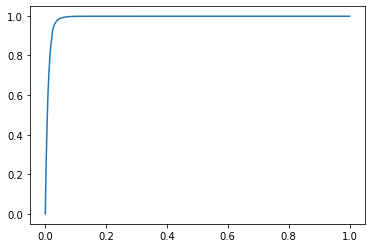

In [91]:
model = nengo.Network()
with model:
    
    stim = nengo.Node(1)
    
    tau_synapse = 0.1
    tau_desired = 0.01
    
    ens = nengo.Ensemble(n_neurons=500, dimensions=1, neuron_type=nengo.LIFRate())
    c_feedback = nengo.Connection(ens, ens, function=lambda x: (1-tau_synapse/tau_desired)*x, synapse=tau_synapse)
    c_forward = nengo.Connection(stim, ens, function=lambda x: (tau_synapse/tau_desired)*x, synapse=tau_synapse)

    
    xw = 0.025
    xf = 0.1
    cx = 3/13
    ax = -cx/(3*xw**2)
    
    #c_feedback = nengo.Connection(ens, ens, function=lambda x: tau_synapse*(cx*x+ax*x**3)+x, synapse=tau_synapse)
    #c_forward = nengo.Connection(stim, ens, function=lambda x: tau_synapse*x, synapse=tau_synapse)
    
    p_ens_input = nengo.Probe(c_forward)
    
    p_stim = nengo.Probe(stim)
    p_ens = nengo.Probe(ens)
    
sim = nengo.Simulator(model)
sim.run(1)
    
plt.plot(sim.trange(), sim.data[p_ens])

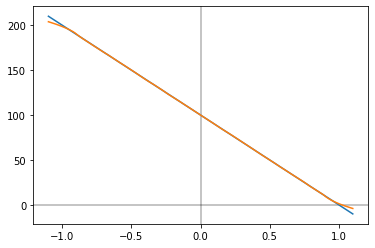

In [93]:
def plot_target_dynamics(sim, c_feedback, domain, p_input):
    tau = c_feedback.synapse.tau
    f = c_feedback.function
    
    _, a = nengo.utils.ensemble.tuning_curves(c_feedback.pre, sim, domain[:,None])
    dec = sim.data[c_feedback].weights
    
    v = (a @ dec.T) [:,0]
    
    u = sim.data[p_input][-1] / tau
    y = (f(domain)-domain)/tau + u
    y2 = (v-domain)/tau + u

    plt.axhline(0, c='k', alpha=0.3)
    plt.axvline(0, c='k', alpha=0.3)
    plt.plot(domain, y)
    plt.plot(domain, y2)
    #plt.ylim(-10,10)
        
plot_target_dynamics(sim, c_feedback, domain=np.linspace(-1.1, 1.1, 1000), p_input=p_ens_input)

In [90]:
# dx/dt = -x/tau + u/tau

In [68]:
nengo.utils.ensemble.

<module 'nengo.utils.ensemble' from 'C:\\Users\\terry\\anaconda3\\lib\\site-packages\\nengo\\utils\\ensemble.py'>

In [107]:
for k,v in sim.signals.items():
    print(repr(k.name))
    if k.name == c_forward:
        print(k)

'step'
'time'
'<Ensemble (unlabeled) at 0x24df05ff430>.bias'
'<Ensemble (unlabeled) at 0x24df05ff430>.neuron_in'
'<Ensemble (unlabeled) at 0x24df05ff430>.neuron_out'
'<Ensemble (unlabeled) at 0x24df05ff430>.scaled_encoders'
"merged<<Ensemble (unlabeled) at 0x24df05ff430>.signal, ..., <Probe of 'decoded_output' of <Ensemble (unlabeled) at 0x24df05ff430>>>"
"merged<<Ensemble (unlabeled) at 0x24df05ff430>.signal, ..., <Probe of 'decoded_output' of <Ensemble (unlabeled) at 0x24df05ff430>>>[(slice(0, 1, None),)]"
'merged<Dense(shape=(1, 1)).weighted, ..., Dense(shape=(1, 1)).weighted>'
'merged<Dense(shape=(1, 1)).weighted, ..., Dense(shape=(1, 1)).weighted>[(slice(1, 2, None),)]'
'Dense(shape=(1, 1)).weighted.Lowpass(tau=0.1)'
'0x24df0600400'
'<Node (unlabeled) at 0x24df05ff0d0>.out'
"<Connection from <Node (unlabeled) at 0x24df05ff0d0> to <Ensemble (unlabeled) at 0x24df05ff430> computing '<lambda>'>.func"
"<Connection from <Node (unlabeled) at 0x24df05ff0d0> to <Ensemble (unlabeled) at 0x2

In [108]:
sim.signals[repr(c_forward)+'.func']

KeyError: "<Connection at 0x24df05ff400 from <Node (unlabeled) at 0x24df05ff0d0> to <Ensemble (unlabeled) at 0x24df05ff430> computing '<lambda>'>.func"

In [103]:
for k in sim.data.keys():
    print(k)

<Ensemble (unlabeled) at 0x24df05ff430>
<Node (unlabeled) at 0x24df05ff0d0>
<Connection from <Ensemble (unlabeled) at 0x24df05ff430> to <Ensemble (unlabeled) at 0x24df05ff430> computing '<lambda>'>
<Connection from <Node (unlabeled) at 0x24df05ff0d0> to <Ensemble (unlabeled) at 0x24df05ff430> computing '<lambda>'>
<Probe of 'output' of <Connection from <Node (unlabeled) at 0x24df05ff0d0> to <Ensemble (unlabeled) at 0x24df05ff430> computing '<lambda>'>>
<Probe of 'output' of <Node (unlabeled) at 0x24df05ff0d0>>
<Connection from <Ensemble (unlabeled) at 0x24df05ff430> to <Probe of 'decoded_output' of <Ensemble (unlabeled) at 0x24df05ff430>>>
<Probe of 'decoded_output' of <Ensemble (unlabeled) at 0x24df05ff430>>
<Network (unlabeled) at 0x24df05ff130>


In [104]:
sim.data[c_feedback]

BuiltConnection(eval_points=array([[ 5.50041007e-01],
       [ 9.84041007e-01],
       [ 6.70041007e-01],
       [ 5.64041007e-01],
       [ 2.88041007e-01],
       [ 5.72041007e-01],
       [ 7.52041007e-01],
       [ 3.32041007e-01],
       [-2.39687553e-01],
       [ 4.98041007e-01],
       [-8.27687553e-01],
       [ 9.04041007e-01],
       [-9.71687553e-01],
       [ 1.52041007e-01],
       [ 2.90041007e-01],
       [-5.36875533e-02],
       [ 8.58041007e-01],
       [ 2.50041007e-01],
       [-6.69687553e-01],
       [ 7.48041007e-01],
       [-6.97687553e-01],
       [-9.97687553e-01],
       [ 5.96041007e-01],
       [-6.51687553e-01],
       [ 5.08041007e-01],
       [ 6.60410071e-02],
       [ 3.26041007e-01],
       [-4.13687553e-01],
       [ 1.58041007e-01],
       [-6.53687553e-01],
       [ 6.08041007e-01],
       [ 5.10041007e-01],
       [-6.37687553e-01],
       [-3.59687553e-01],
       [-2.77687553e-01],
       [ 3.94041007e-01],
       [-7.09687553e-01],
       [ 7